Como Método a seguir / modelo de referencia uno puede generalizarlo a los siguientes pasos:

Igual que en la teórica, plantear un problema de Programación Lineal implica siempre los mismos pasos.
Los organizamos en 5:

# *Definir ➔ Formular ➔ Programar ➔ Resolver ➔ Interpretar*

| Paso | ¿Qué hacemos? |
|---|---|
| 1️⃣ Definir | Entender el problema: ¿qué podemos decidir? ¿qué datos tenemos? |
| 2️⃣ Formular | Escribir el modelo en lenguaje matemático (como en la teórica, antes de programar) |
| 3️⃣ Programar | Traducir esa formulación a código con PuLP |
| 4️⃣ Resolver | Correr el solver |
| 5️⃣ Interpretar | Leer el resultado **como técnico**, y decidir |


# Caso Aplicado: Manager Fifa 15 del Barcelona

Nos ponemos en el lugar de la **dirección deportiva del FC Barcelona**. Terminó la temporada, hubo
retiros y ventas, y quedaron **3 posiciones vacantes** en el plantel:

* 1️⃣ Lateral Derecho
* 2️⃣ Mediocampista Central
* 3️⃣ Delantero Centro

Tenemos una base de datos de jugadores (SoFIFA, temporada FIFA 15) con el rating, el valor de mercado y
el salario de cada uno. Vamos a usar **Programación Lineal, tal como la vimos en la teórica**, para
construir una **herramienta de apoyo a la decisión**: el modelo no va a "elegir por nosotros", sino que
nos va a decir **cuánto peso conviene ponerle a cada candidato**, respetando el presupuesto y el salario
disponibles. La decisión final — a quién fichar realmente — va a quedar en manos del **técnico** (vos).

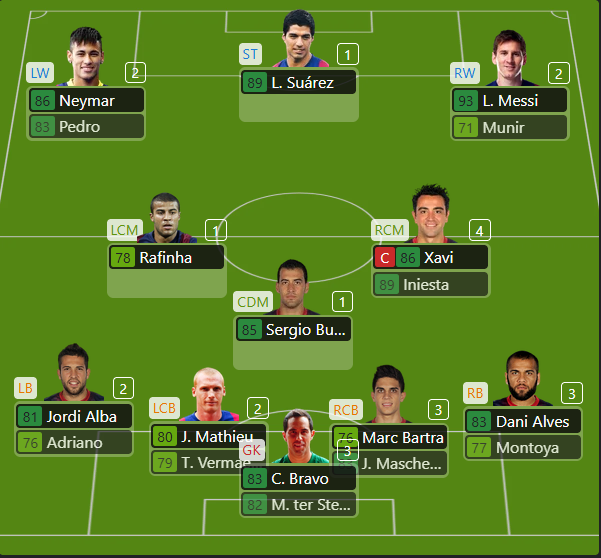

### 1️⃣ DEFINIR

Empecemos por cargar el dataset y mirar qué tiene adentro usando `pandas`

(recordá la teorica de la notebook N01 y el método visto en la practica bajada a tierra N01 *Cargar ➔ Explorar ➔ Transformar*).

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/fglsr0912b/Base-Datos-Genericas/refs/heads/main/players_15.csv"
df = pd.read_csv(url)

print("Cantidad de jugadores y de columnas:", df.shape)
print("\n")

df.head()

Cantidad de jugadores y de columnas: (16155, 110)




/tmp/ipykernel_1173/3621622606.py:4: DtypeWarning: Columns (104) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,CF,93,95,100500000.0,550000.0,27,...,45+3,45+3,45+3,54+3,15+3,https://cdn.sofifa.net/players/158/023/15_120.png,https://cdn.sofifa.net/teams/241/60.png,https://cdn.sofifa.net/flags/es.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"LW, LM",92,92,79000000.0,375000.0,29,...,52+3,52+3,52+3,57+3,16+3,https://cdn.sofifa.net/players/020/801/15_120.png,https://cdn.sofifa.net/teams/243/60.png,https://cdn.sofifa.net/flags/es.png,https://cdn.sofifa.net/teams/1354/60.png,https://cdn.sofifa.net/flags/pt.png
2,9014,https://sofifa.com/player/9014/arjen-robben/15...,A. Robben,Arjen Robben,"RM, LM, RW",90,90,54500000.0,275000.0,30,...,46+3,46+3,46+3,55+3,14+3,https://cdn.sofifa.net/players/009/014/15_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/105035/60.png,https://cdn.sofifa.net/flags/nl.png
3,41236,https://sofifa.com/player/41236/zlatan-ibrahim...,Z. Ibrahimović,Zlatan Ibrahimović,ST,90,90,52500000.0,275000.0,32,...,55+3,55+3,55+3,56+3,17+3,https://cdn.sofifa.net/players/041/236/15_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1363/60.png,https://cdn.sofifa.net/flags/se.png
4,167495,https://sofifa.com/player/167495/manuel-neuer/...,M. Neuer,Manuel Peter Neuer,GK,90,90,63500000.0,300000.0,28,...,38+3,38+3,38+3,36+3,87+3,https://cdn.sofifa.net/players/167/495/15_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1337/60.png,https://cdn.sofifa.net/flags/de.png


In [2]:
#Vemos que columnas tiene, corroboramos si es lo que creiamos...
print("\nCOLUMNAS :", list(df.columns))

print("\n")

# ¿De qué tipo es cada columna y hay datos faltantes (nulos)?
df.info()

print("\n")

# Resumen estadístico rápido (promedio de cuentas, propina máxima, etc.)
df.describe()


COLUMNAS : ['sofifa_id', 'player_url', 'short_name', 'long_name', 'player_positions', 'overall', 'potential', 'value_eur', 'wage_eur', 'age', 'dob', 'height_cm', 'weight_kg', 'club_team_id', 'club_name', 'league_name', 'league_level', 'club_position', 'club_jersey_number', 'club_loaned_from', 'club_joined', 'club_contract_valid_until', 'nationality_id', 'nationality_name', 'nation_team_id', 'nation_position', 'nation_jersey_number', 'preferred_foot', 'weak_foot', 'skill_moves', 'international_reputation', 'work_rate', 'body_type', 'real_face', 'release_clause_eur', 'player_tags', 'player_traits', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_bala

,sofifa_id,overall,potential,value_eur,wage_eur,age,height_cm,weight_kg,club_team_id,league_level,...,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed
count,16155.000000,16155.000000,16155.000000,1.584400e+04,15916.000000,16155.000000,16155.000000,16155.000000,15916.000000,15916.000000,...,0.0,16155.000000,16155.000000,16155.000000,16155.000000,16155.000000,16155.000000,16155.000000,16155.000000,1775.000000
mean,189298.540699,63.830393,68.350108,1.081706e+06,13252.513194,24.776230,181.083627,75.474342,39905.174353,1.378424,...,NaN,45.009037,47.656639,45.885918,15.869514,15.511668,15.354875,15.504735,15.998514,43.865915
std,39762.547872,7.169896,6.580610,2.842704e+06,23608.922510,4.625321,6.618974,6.891796,52050.202038,0.736796,...,NaN,17.915206,18.743105,18.145497,17.576799,16.414173,16.010498,16.585081,17.983209,8.484421
min,2.000000,40.000000,40.000000,1.000000e+03,2000.000000,16.000000,155.000000,50.000000,1.000000,1.000000,...,NaN,20.000000,20.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,20.000000
25%,178042.500000,59.000000,64.000000,1.300000e+05,2000.000000,21.000000,176.000000,70.000000,379.000000,1.000000,...,NaN,25.000000,25.000000,25.000000,8.000000,8.000000,8.000000,8.000000,8.000000,39.000000
50%,200844.000000,64.000000,68.000000,3.500000e+05,5000.000000,24.000000,181.000000,75.000000,1843.000000,1.000000,...,NaN,46.000000,52.000000,49.000000,11.000000,11.000000,11.000000,10.000000,10.000000,44.000000
75%,214349.500000,68.000000,73.000000,8.250000e+05,10000.000000,28.000000,186.000000,80.000000,110398.000000,2.000000,...,NaN,61.000000,64.000000,62.000000,13.000000,14.000000,13.000000,13.000000,13.000000,49.000000
max,254664.000000,93.000000,95.000000,1.005000e+08,550000.000000,44.000000,204.000000,110.000000,113147.000000,4.000000,...,NaN,90.000000,91.000000,95.000000,88.000000,87.000000,92.000000,90.000000,90.000000,66.000000


El dataset tiene muchísimas columnas (habilidades, club, nacionalidad, fotos, etc.). Para nuestro
problema solo nos importan unas pocas.

In [3]:
columnas_de_interes = ["short_name", "player_positions", "age", "overall", "potential",
                       "value_eur", "wage_eur", "club_name", "nationality_name"]

df[columnas_de_interes].head(10)

,short_name,player_positions,age,overall,potential,value_eur,wage_eur,club_name,nationality_name
0,L. Messi,CF,27,93,95,100500000.0,550000.0,FC Barcelona,Argentina
1,Cristiano Ronaldo,"LW, LM",29,92,92,79000000.0,375000.0,Real Madrid CF,Portugal
2,A. Robben,"RM, LM, RW",30,90,90,54500000.0,275000.0,FC Bayern München,Netherlands
3,Z. Ibrahimović,ST,32,90,90,52500000.0,275000.0,Paris Saint-Germain,Sweden
4,M. Neuer,GK,28,90,90,63500000.0,300000.0,FC Bayern München,Germany
5,Iniesta,"CM, LW",30,89,89,36000000.0,250000.0,FC Barcelona,Spain
6,L. Suárez,"ST, CF",27,89,91,49500000.0,300000.0,FC Barcelona,Uruguay
7,R. van Persie,ST,30,88,88,40500000.0,230000.0,Manchester United,Netherlands
8,B. Schweinsteiger,"CM, CDM",29,88,88,39000000.0,200000.0,FC Bayern München,Germany
9,F. Ribéry,LM,31,88,88,33000000.0,200000.0,FC Bayern München,France


* `player_positions`: la o las posiciones en las que juega (ej: `"CM, CDM"`)
* `overall`: el rating actual del jugador (0 a 99)
* `value_eur`: el valor de mercado, en euros
* `wage_eur`: el salario semanal, en euros





Ahora sí, armemos el universo de **candidatos**: de todo `df`, nos quedamos solo con los jugadores que
juegan en una de las 3 posiciones que busca el club, que tengan un nivel razonable (overall alto), que
tengan datos de mercado cargados, y que no sean ya del propio Barcelona.

In [4]:
# Nos quedamos con la PRIMERA posición que lista cada jugador, para simplificar
df["posicion_principal"] = df["player_positions"].apply(lambda p: p.split(",")[0].strip())

# Armamos por separado los candidatos para cada una de las 3 posiciones que buscamos...
candidatos_lateral = df[df["posicion_principal"] == "RB"].copy()
candidatos_lateral["posicion_buscada"] = "Lateral Derecho"

candidatos_medio = df[df["posicion_principal"] == "CM"].copy()
candidatos_medio["posicion_buscada"] = "Mediocampista Central"

candidatos_delantero = df[df["posicion_principal"].isin(["ST", "CF"])].copy()
candidatos_delantero["posicion_buscada"] = "Delantero Centro"

# ... y los juntamos en un solo dataframe
candidatos = pd.concat([candidatos_lateral, candidatos_medio, candidatos_delantero])

print("Candidatos encontrados por posición (antes de filtrar por calidad):")
print(f"\n{candidatos["posicion_buscada"].value_counts()}")

Candidatos encontrados por posición (antes de filtrar por calidad):

posicion_buscada
Delantero Centro         2608
Mediocampista Central    1955
Lateral Derecho          1220
Name: count, dtype: int64


Ahora filtramos por calidad mínima y descartamos filas con datos incompletos o que ya son del
Barcelona (no tiene sentido "fichar" a alguien que ya está en el club):

In [5]:
candidatos = candidatos[
    (candidatos["overall"] >= 75)
    & (candidatos["value_eur"].notna())
    & (candidatos["wage_eur"].notna())
    & (candidatos["club_name"] != "FC Barcelona")
].copy()

candidatos = candidatos[["sofifa_id", "short_name", "club_name", "posicion_buscada",
                          "overall", "value_eur", "wage_eur", "age"]].reset_index(drop=True)

print("Candidatos finales por posición:")
print(f"\n {candidatos["posicion_buscada"].value_counts()}")
print("\nTotal de candidatos:", len(candidatos))

print("\n")

candidatos.sort_values("overall", ascending=False).head(10)

Candidatos finales por posición:

 posicion_buscada
Delantero Centro         181
Mediocampista Central    120
Lateral Derecho           57
Name: count, dtype: int64

Total de candidatos: 358




,sofifa_id,short_name,club_name,posicion_buscada,overall,value_eur,wage_eur,age
177,41236,Z. Ibrahimović,Paris Saint-Germain,Delantero Centro,90,52500000.0,275000.0,32
57,121944,B. Schweinsteiger,FC Bayern München,Mediocampista Central,88,39000000.0,200000.0,29
179,167397,Falcao,Manchester United,Delantero Centro,88,46500000.0,250000.0,28
178,7826,R. van Persie,Manchester United,Delantero Centro,88,40500000.0,230000.0,30
180,188545,R. Lewandowski,FC Bayern München,Delantero Centro,87,44000000.0,210000.0,25
58,177003,L. Modrić,Real Madrid CF,Mediocampista Central,87,36500000.0,220000.0,28
182,153079,S. Agüero,Manchester City,Delantero Centro,86,45500000.0,230000.0,26
181,54050,W. Rooney,Manchester United,Delantero Centro,86,40000000.0,230000.0,28
59,20289,Y. Touré,Manchester City,Mediocampista Central,86,28500000.0,190000.0,31
186,179844,Diego Costa,Chelsea,Delantero Centro,85,26500000.0,170000.0,25


Podemos mirar, con describe, funcion de Pandas vista antes en las clases cómo se distribuyen los valores de mercado y los salarios entre estos candidatos en determinadas columnas del dataframe:


In [6]:
candidatos[["value_eur", "wage_eur"]].describe()

,value_eur,wage_eur
count,3.580000e+02,358.000000
mean,7.898771e+06,79902.234637
std,7.145372e+06,39224.684184
min,1.100000e+05,25000.000000
25%,4.000000e+06,50000.000000
50%,5.500000e+06,70000.000000
75%,9.000000e+06,90000.000000
max,5.250000e+07,275000.000000


### 2️⃣ FORMULAR: el modelo en lenguaje matemático

**Variable de decisión.** Igual que en el Caso 4 de la teórica (donde $x_1, x_2, x_3, x_4$ eran
**cantidades continuas** a producir), acá definimos, para cada jugador candidato $i$:

$$x_i = \text{"peso" o prioridad que el modelo le asigna al jugador } i, \qquad 0 \leq x_i \leq 1$$

$x_i$ **no** es una decisión de sí/no: es un puntaje continuo. Un valor cercano a 1 significa que el
modelo recomienda fuertemente a ese candidato; un valor cercano a 0, que casi no lo tiene en cuenta.
Cuando dos candidatos de una misma posición queden con puntajes parecidos, **ahí entra el criterio del
técnico** (vos) para decidir a quién ficha realmente el club — el modelo da apoyo a la decisión, no la
reemplaza.

**Función objetivo.** Maximizar el rating total ponderado por esos pesos:

$$\max Z = \sum_{i} overall_i \cdot x_i$$

**Restricciones** (misma lógica que las restricciones de tierra/agua/horas del Caso 4, adaptadas a
nuestro problema):

1. Los pesos de cada posición suman 1: $\sum_{i \in \text{Lateral}} x_i = 1$ (e igual para las otras dos)
2. Presupuesto de transferencias: $\sum_i value_i \cdot x_i \leq B$
3. Tope salarial: $\sum_i wage_i \cdot x_i \leq W$
4. Ningún peso para jugadores del Real Madrid: $x_i = 0$ para todo $i$ del Real Madrid
5. Edad promedio ponderada $\leq$ 27 años: $\sum_i age_i \cdot x_i \leq 3 \times 27$
6. $0 \leq x_i \leq 1$ para todo $i$

### 3️⃣ PROGRAMAR: armamos el modelo con PuLP

Tenemos presente la funcion objetivo y las restricciones

Lo construimos con (`LpProblem`, `+=`, `.solve()`).

Para cada restricción
vamos a repetir siempre el mismo patrón: **recorrer los candidatos con un `for`, guardar cada término en
una lista, y sumarlos con `pulp.lpSum`**



In [7]:
%pip install Pulp

import pulp

# Parámetros que nos da la dirección deportiva, en este problema

PRESUPUESTO_TRANSFERENCIAS = 80_000_000   # euros disponibles para los 3 fichajes
TOPE_SALARIAL              = 500_000      # euros semanales disponibles para los 3
EDAD_PROMEDIO_MAXIMA       = 27           # edad promedio máxima admitida

modelo = pulp.LpProblem("Fichajes_FC_Barcelona", pulp.LpMaximize)

**Variables de decisión**: una por candidato, continua entre 0 y 1 — igual que
`pulp.LpVariable("Trigo", lowBound=0)` en el Caso 4, solo que acá además le ponemos un techo (`upBound=1`)
porque un "peso" no puede superar el 100%.

In [8]:
ids_candidatos = list(candidatos["sofifa_id"])

x = pulp.LpVariable.dicts("Peso", ids_candidatos, lowBound=0, upBound=1)

print("Se crearon", len(x), "variables continuas entre 0 y 1 (una por candidato).")

Se crearon 358 variables continuas entre 0 y 1 (una por candidato).


**Función objetivo**: recorremos cada candidato, multiplicamos su `overall` por su peso $x_i$, y
sumamos todo.

In [9]:
terminos_objetivo = []
for jugador in candidatos.itertuples():
    terminos_objetivo.append(jugador.overall * x[jugador.sofifa_id])

modelo += pulp.lpSum(terminos_objetivo), "Z"

print("Función objetivo cargada: maximizar el Overall total, ponderado por los pesos.")

Función objetivo cargada: maximizar el Overall total, ponderado por los pesos.


**Restricción de posiciones**: para cada una de las 3 posiciones, la suma de los pesos de sus
candidatos tiene que dar exactamente 1 (repartimos el 100% de la decisión entre esos candidatos).

In [10]:
for posicion in ["Lateral Derecho", "Mediocampista Central", "Delantero Centro"]:
    jugadores_de_esa_posicion = candidatos[candidatos["posicion_buscada"] == posicion]

    terminos = []
    for jugador in jugadores_de_esa_posicion.itertuples():
        terminos.append(x[jugador.sofifa_id])

    modelo += pulp.lpSum(terminos) == 1
    print(f"Restricción agregada: los pesos de {posicion} suman 1")

Restricción agregada: los pesos de Lateral Derecho suman 1
Restricción agregada: los pesos de Mediocampista Central suman 1
Restricción agregada: los pesos de Delantero Centro suman 1


**Presupuesto y salario** (las 2 restricciones centrales del caso): mismo patrón, cambiando qué
columna usamos.

In [11]:
terminos_presupuesto = []
terminos_salario = []
for jugador in candidatos.itertuples():
    terminos_presupuesto.append(jugador.value_eur * x[jugador.sofifa_id])
    terminos_salario.append(jugador.wage_eur * x[jugador.sofifa_id])

modelo += pulp.lpSum(terminos_presupuesto) <= PRESUPUESTO_TRANSFERENCIAS
modelo += pulp.lpSum(terminos_salario) <= TOPE_SALARIAL

print("Restricciones de presupuesto y salario agregadas.")

Restricciones de presupuesto y salario agregadas.


**Dos restricciones extra**, para que el caso se parezca más a la realidad: nada de ponerle peso a
jugadores del Real Madrid, y que el trío no sea, en promedio, demasiado grande de edad.

In [12]:
terminos_real_madrid = []
terminos_edad = []
for jugador in candidatos.itertuples():
    if jugador.club_name == "Real Madrid CF":
        terminos_real_madrid.append(x[jugador.sofifa_id])
    terminos_edad.append(jugador.age * x[jugador.sofifa_id])

modelo += pulp.lpSum(terminos_real_madrid) == 0
modelo += pulp.lpSum(terminos_edad) <= 3 * EDAD_PROMEDIO_MAXIMA

print("Restricciones adicionales agregadas: sin jugadores del Real Madrid, edad promedio limitada.")
print("\nEl modelo quedó armado con", len(modelo.constraints), "restricciones y", len(x), "variables.")

Restricciones adicionales agregadas: sin jugadores del Real Madrid, edad promedio limitada.

El modelo quedó armado con 7 restricciones y 358 variables.


### 4️⃣ RESOLVER
`modelo.solve()`. Antes de mirar el resultado, siempre conviene chequear el
`status`: nos dice si el solver realmente encontró una solución posible.

In [13]:
modelo.solve()
status = pulp.LpStatus[modelo.status]

print("Status del solver:", status)

if status != "Optimal":
    print("⚠️ No se encontró una solución. Probá subir el presupuesto o el tope salarial y volver a correr.")
else:
    print("Talento total (Overall) ponderado:", pulp.value(modelo.objective))

Status del solver: Optimal
Talento total (Overall) ponderado: 254.79032259000002


### 5️⃣ INTERPRETAR: leemos los puntajes **como técnico**

**Puntaje que el modelo le asignó a cada candidato**, posición por posición.

Cuando un candidato se queda con (casi) todo el peso, la recomendación es clara. Cuando el peso queda
repartido entre dos o más candidatos parecidos, es una señal de que **el modelo no puede distinguirlos
mejor con la información que tiene** — y ahí el técnico tiene que mirar otras cosas (estado físico,
adaptación, preferencia del entrenador) para desempatar.

In [14]:
agregamos_columna_peso = candidatos.copy()
agregamos_columna_peso["peso"] = [x[i].varValue for i in agregamos_columna_peso["sofifa_id"]]

for posicion in ["Lateral Derecho", "Mediocampista Central", "Delantero Centro"]:
    print(f"📋 {posicion}")
    candidatos_posicion = agregamos_columna_peso[agregamos_columna_peso["posicion_buscada"] == posicion]
    candidatos_posicion = candidatos_posicion[candidatos_posicion["peso"] > 0.001]
    candidatos_posicion = candidatos_posicion.sort_values("peso", ascending=False)
    for _, jugador in candidatos_posicion.iterrows():
        print(f"    {jugador['short_name']:<20} peso = {jugador['peso']:.2f}   "
              f"(Overall {jugador['overall']:.0f}, €{jugador['value_eur']:,.0f}, €{jugador['wage_eur']:,.0f}/sem)")
    print()

📋 Lateral Derecho
    Ł. Piszczek          peso = 1.00   (Overall 82, €12,500,000, €120,000/sem)

📋 Mediocampista Central
    P. Pogba             peso = 0.61   (Overall 83, €13,500,000, €120,000/sem)
    B. Schweinsteiger    peso = 0.39   (Overall 88, €39,000,000, €200,000/sem)

📋 Delantero Centro
    Z. Ibrahimović       peso = 0.41   (Overall 90, €52,500,000, €275,000/sem)
    R. Lewandowski       peso = 0.39   (Overall 87, €44,000,000, €210,000/sem)
    Diego Costa          peso = 0.20   (Overall 85, €26,500,000, €170,000/sem)



**Como técnico, la lectura más simple es**: en cada posición, quedarnos con el candidato de mayor
peso — es la recomendación del modelo.

Armamos esa "propuesta" concreta y **chequeamos si de verdad entra**
dentro del presupuesto, el salario y la edad promedio:

In [15]:
recomendacion = (
    agregamos_columna_peso
    .sort_values("peso", ascending=False)
    .groupby("posicion_buscada")
    .first()
    .reset_index()
)

print("🏟️  RECOMENDACIÓN DEL MODELO (mayor peso por posición)\n")
for _, jugador in recomendacion.iterrows():
    print(f"{jugador['posicion_buscada']:<25} {jugador['short_name']:<20} "
          f"Overall {jugador['overall']:.0f}  |  €{jugador['value_eur']:,.0f}  |  €{jugador['wage_eur']:,.0f}/sem  "
          f"|  peso {jugador['peso']:.2f}")

gasto_transferencias = recomendacion["value_eur"].sum()
gasto_salarial = recomendacion["wage_eur"].sum()
edad_promedio = recomendacion["age"].mean()

print(f"\n💰 Presupuesto que usaría esta combinación puntual: €{gasto_transferencias:,.0f} de €{PRESUPUESTO_TRANSFERENCIAS:,.0f}")
print(f"💵 Salario semanal que comprometería: €{gasto_salarial:,.0f} de €{TOPE_SALARIAL:,.0f}")
print(f"🎂 Edad promedio del trío: {edad_promedio:.1f} años (máximo admitido: {EDAD_PROMEDIO_MAXIMA})")

entra_en_presupuesto = gasto_transferencias <= PRESUPUESTO_TRANSFERENCIAS
entra_en_salario = gasto_salarial <= TOPE_SALARIAL
entra_en_edad = edad_promedio <= EDAD_PROMEDIO_MAXIMA

if entra_en_presupuesto and entra_en_salario and entra_en_edad:
    print("\n✅ Esta combinación puntual respeta el presupuesto, el salario y la edad promedio:")
    print("   es una propuesta concreta y viable para llevarle a la dirección deportiva.")
else:
    print("\n⚠️  Esta combinación puntual NO respeta alguna restricción, aunque el modelo en su")
    print("   conjunto sí las cumple (porque reparte el peso de forma fraccionada entre varios")
    print("   candidatos a la vez). Como técnico, probá reemplazar al candidato más caro o de mayor")
    print("   salario de la posición más cara por su 'competidor' de la tabla de arriba, y volvé a sumar.")

🏟️  RECOMENDACIÓN DEL MODELO (mayor peso por posición)

Delantero Centro          Z. Ibrahimović       Overall 90  |  €52,500,000  |  €275,000/sem  |  peso 0.41
Lateral Derecho           Ł. Piszczek          Overall 82  |  €12,500,000  |  €120,000/sem  |  peso 1.00
Mediocampista Central     P. Pogba             Overall 83  |  €13,500,000  |  €120,000/sem  |  peso 0.61

💰 Presupuesto que usaría esta combinación puntual: €78,500,000 de €80,000,000
💵 Salario semanal que comprometería: €515,000 de €500,000
🎂 Edad promedio del trío: 27.3 años (máximo admitido: 27)

⚠️  Esta combinación puntual NO respeta alguna restricción, aunque el modelo en su
   conjunto sí las cumple (porque reparte el peso de forma fraccionada entre varios
   candidatos a la vez). Como técnico, probá reemplazar al candidato más caro o de mayor
   salario de la posición más cara por su 'competidor' de la tabla de arriba, y volvé a sumar.


## 🔍 ¿Qué pasaría si aumentamos el presupuesto?

Igual que antes: la forma más simple de responder es **volver a resolver el mismo modelo, cambiando solo
el presupuesto**, y comparar el resultado.

In [16]:
PRESUPUESTO_ALTERNATIVO = 120_000_000   # subimos el presupuesto un 50%

modelo_2 = pulp.LpProblem("Fichajes_FC_Barcelona_presupuesto_alto", pulp.LpMaximize)
x2 = pulp.LpVariable.dicts("Peso2", ids_candidatos, lowBound=0, upBound=1)

terminos_objetivo_2 = []
for jugador in candidatos.itertuples():
    terminos_objetivo_2.append(jugador.overall * x2[jugador.sofifa_id])
modelo_2 += pulp.lpSum(terminos_objetivo_2), "Z"

for posicion in ["Lateral Derecho", "Mediocampista Central", "Delantero Centro"]:
    jugadores_de_esa_posicion = candidatos[candidatos["posicion_buscada"] == posicion]
    terminos = [x2[jugador.sofifa_id] for jugador in jugadores_de_esa_posicion.itertuples()]
    modelo_2 += pulp.lpSum(terminos) == 1

terminos_presupuesto_2, terminos_salario_2, terminos_rm_2, terminos_edad_2 = [], [], [], []
for jugador in candidatos.itertuples():
    terminos_presupuesto_2.append(jugador.value_eur * x2[jugador.sofifa_id])
    terminos_salario_2.append(jugador.wage_eur * x2[jugador.sofifa_id])
    terminos_edad_2.append(jugador.age * x2[jugador.sofifa_id])
    if jugador.club_name == "Real Madrid CF":
        terminos_rm_2.append(x2[jugador.sofifa_id])

modelo_2 += pulp.lpSum(terminos_presupuesto_2) <= PRESUPUESTO_ALTERNATIVO
modelo_2 += pulp.lpSum(terminos_salario_2) <= TOPE_SALARIAL
modelo_2 += pulp.lpSum(terminos_rm_2) == 0
modelo_2 += pulp.lpSum(terminos_edad_2) <= 3 * EDAD_PROMEDIO_MAXIMA

modelo_2.solve()
print("Status:", pulp.LpStatus[modelo_2.status])
print("Talento total ponderado con presupuesto de €{:,.0f}: {:.1f}".format(
    PRESUPUESTO_ALTERNATIVO, pulp.value(modelo_2.objective)))

Status: Optimal
Talento total ponderado con presupuesto de €120,000,000: 255.5


> Vemos que al aumentar un 50% el presupuesto, solo aumento un 1% el talento total.. (en realidad menos de un 0,5% fue el aumento...)

Por ende aumentar el presupuesto no nos da mas calidad, hay otra restriccion que nos limita el Salto de calidad



`Extra`


**Gráfico 1**: el peso que el modelo le puso a cada candidato, dentro de cada posición.


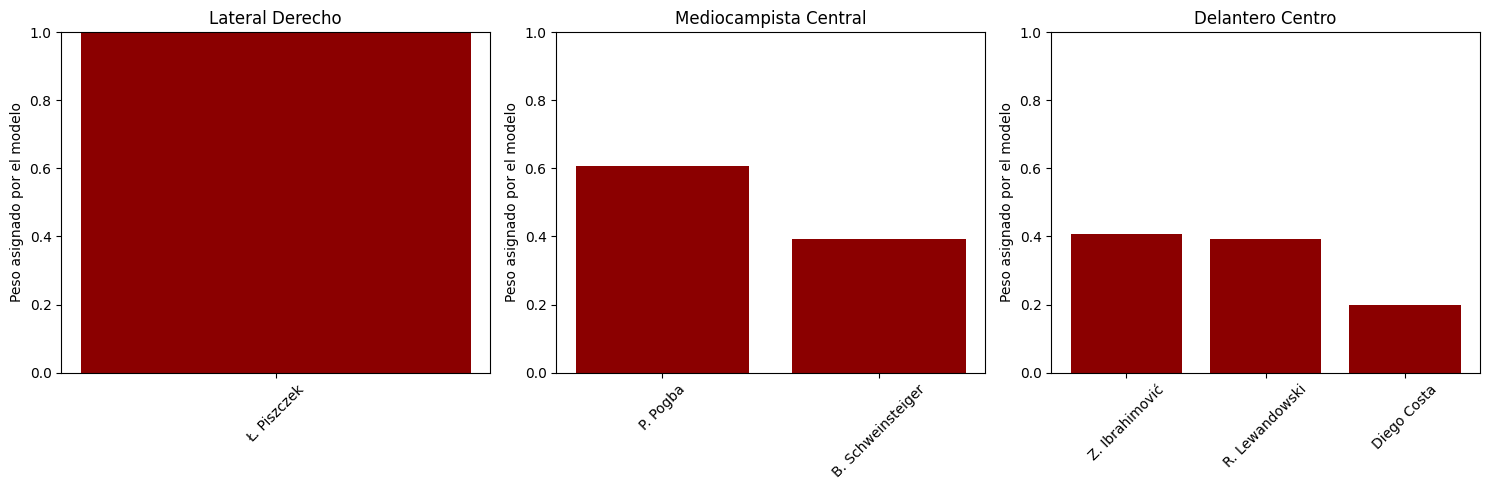

In [17]:
import matplotlib.pyplot as plt

fig, ejes = plt.subplots(1, 3, figsize=(15, 5))

for eje, posicion in zip(ejes, ["Lateral Derecho", "Mediocampista Central", "Delantero Centro"]):
    datos_posicion = agregamos_columna_peso[agregamos_columna_peso["posicion_buscada"] == posicion]
    datos_posicion = datos_posicion[datos_posicion["peso"] > 0.001].sort_values("peso", ascending=False)

    eje.bar(datos_posicion["short_name"], datos_posicion["peso"], color="darkred")
    eje.set_title(posicion)
    eje.set_ylabel("Peso asignado por el modelo")
    eje.set_ylim(0, 1)
    eje.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Gráfico 2**: comparamos el talento total logrado con el presupuesto original y con el
presupuesto alternativo (Paso "¿qué pasaría si...?").

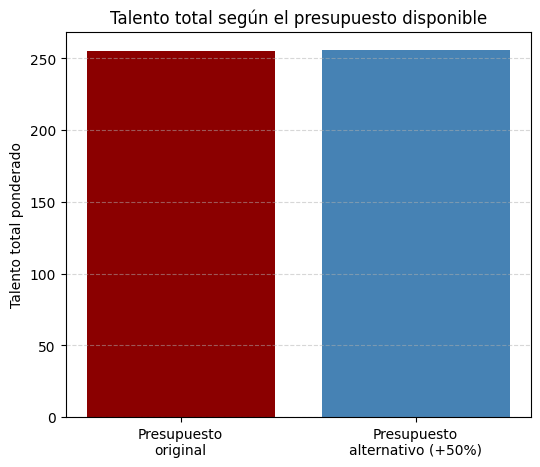

In [18]:
escenarios = ["Presupuesto\noriginal", "Presupuesto\nalternativo (+50%)"]
talento_total = [pulp.value(modelo.objective), pulp.value(modelo_2.objective)]

plt.figure(figsize=(6, 5))
plt.bar(escenarios, talento_total, color=["darkred", "steelblue"])
plt.ylabel("Talento total ponderado")
plt.title("Talento total según el presupuesto disponible")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

## 🏁 Cierre

# *Definir ➔ Formular ➔ Programar ➔ Resolver ➔ Interpretar*

| Paso | Qué hicimos |
|---|---|
| Definir | Cargamos el dataset y armamos el universo de candidatos por posición y calidad |
| Formular | Planteamos una variable **continua** (0 a 1) que representa el peso o prioridad de cada candidato |
| Programar | Tradujimos la formulación a código con PuLP, recorriendo los candidatos con `for` |
| Resolver | Corrimos el solver y chequeamos el status |
| Interpretar | Leímos los puntajes como técnico, armamos una recomendación, y la pusimos a prueba subiendo el presupuesto |

La gran diferencia respecto de un modelo de sí/no es que acá **el modelo asesora, y el técnico decide**:
cuando los puntajes están repartidos, es una invitación a usar criterio futbolístico además del
matemático.

*Fuente de datos: SoFIFA (jugadores de FIFA 15).*